<a href="https://www.kaggle.com/code/rabiatahmed/customer-segmentation-clustering-analysis?scriptVersionId=327158921" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Plan
This project applies K-Means clustering to a customer transaction dataset to discover groups using the behavioral and demographic features. The objective is to identify natural groupings within the data that can inform targeted strategies and customer understanding.

In [1]:
# Import standard operational packages.
import numpy as np
import pandas as pd

# Important tools for modeling and evaluation.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Import visualization packages.
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df0 = pd.read_csv('/kaggle/input/datasets/fares279/customers-transactions/Customer_Transactions.csv')

# Display first few rows
df0.head()

,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date
0,1,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,Very satisfied with my purchase.,2025-06-22
1,2,40,Male,India,41041,4,10,31.73,4,29,0.21,0,Good quality and value for money.,2025-10-17
2,3,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,Excellent customer service.,2025-07-01
3,4,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,Good quality and value for money.,2025-08-17
4,5,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,Excellent customer service.,2025-06-21


# Exploratory Data Analysis

In [3]:
# Check number of rows and columns
df0.shape

(10000, 14)

In [4]:
# Check basic information
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   age                       10000 non-null  int64  
 2   gender                    10000 non-null  object 
 3   country                   10000 non-null  object 
 4   annual_income             10000 non-null  int64  
 5   spending_score            10000 non-null  int64  
 6   num_purchases             10000 non-null  int64  
 7   avg_purchase_value        10000 non-null  float64
 8   membership_years          10000 non-null  int64  
 9   website_visits_per_month  10000 non-null  int64  
 10  cart_abandon_rate         10000 non-null  float64
 11  churned                   10000 non-null  int64  
 12  feedback_text             10000 non-null  object 
 13  last_purchase_date        10000 non-null  object 
dtypes: floa

In [5]:
# Change data type
df0['gender'] = df0['gender'].astype('category')

df0['country'] = df0['country'].astype('category')

In [6]:
# Check basic information
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   customer_id               10000 non-null  int64   
 1   age                       10000 non-null  int64   
 2   gender                    10000 non-null  category
 3   country                   10000 non-null  category
 4   annual_income             10000 non-null  int64   
 5   spending_score            10000 non-null  int64   
 6   num_purchases             10000 non-null  int64   
 7   avg_purchase_value        10000 non-null  float64 
 8   membership_years          10000 non-null  int64   
 9   website_visits_per_month  10000 non-null  int64   
 10  cart_abandon_rate         10000 non-null  float64 
 11  churned                   10000 non-null  int64   
 12  feedback_text             10000 non-null  object  
 13  last_purchase_date        10000 non-null  objec

In [7]:
# Get descriptive statistics about the data
df0.describe()

,customer_id,age,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,44.045800,86067.676100,50.924200,22.576000,47.447480,6.340500,15.578100,0.501216,0.109000
std,2886.89568,15.404669,38986.787991,28.753395,10.163639,11.205902,4.680657,8.655322,0.286836,0.311655
min,1.00000,18.000000,20028.000000,1.000000,1.000000,16.750000,0.000000,1.000000,0.000000,0.000000
25%,2500.75000,31.000000,55345.500000,26.000000,14.000000,39.500000,2.000000,8.000000,0.250000,0.000000
50%,5000.50000,44.000000,78339.500000,51.000000,22.000000,46.990000,6.000000,16.000000,0.510000,0.000000
75%,7500.25000,57.000000,115570.500000,75.000000,31.000000,55.080000,10.000000,23.000000,0.750000,0.000000
max,10000.00000,70.000000,179960.000000,100.000000,49.000000,83.270000,15.000000,30.000000,1.000000,1.000000


In [8]:
# Check for duplicates
df0.duplicated().sum()

np.int64(0)

# Feature Engineering

In [9]:
df1 = df0.copy()

# Select columns
df1 = df1[['age', 'annual_income', 'spending_score', 'num_purchases', 'gender', 'country',
           'avg_purchase_value', 'membership_years', 'website_visits_per_month', 'cart_abandon_rate']]

In [10]:
# Output unique values
print(df1['gender'].unique())

print(df1['country'].unique())

['Male', 'Female']
Categories (2, object): ['Female', 'Male']
['Germany', 'India', 'Australia', 'UK', 'Brazil', 'USA', 'Japan', 'France', 'South Africa', 'Canada']
Categories (10, object): ['Australia', 'Brazil', 'Canada', 'France', ..., 'Japan', 'South Africa', 'UK', 'USA']


In [11]:
# Encode categorical variables

df1['gender'] = df1['gender'].apply(lambda x: 1 if x == 'Male' else 0)

df1 = pd.get_dummies(df1, columns=['country'], drop_first = True)

df1.head()

,age,annual_income,spending_score,num_purchases,gender,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,country_South Africa,country_UK,country_USA
0,37,85886,14,18,1,41.20,6,20,0.95,False,False,False,True,False,False,False,False,False
1,40,41041,4,10,1,31.73,4,29,0.21,False,False,False,False,True,False,False,False,False
2,69,143869,59,39,0,65.96,12,26,0.08,False,False,False,False,False,False,False,False,False
3,30,87261,45,34,1,51.87,12,7,0.61,False,False,False,False,False,False,False,True,False
4,69,110678,40,38,0,59.64,13,16,0.49,False,False,False,False,False,False,False,True,False


In [12]:
# Check the number of rows and columns
df1.shape

(10000, 18)

# Construct

In [13]:
# Scale the data
X = df1
X_scaled = StandardScaler().fit_transform(X)

**Evaluate Inertia**

In [14]:
# Create a list from 2-10.
num_clusters = [i for i in range(2, 11)]

def kmeans_inertia(num_clusters, x_vals):
    '''
    Fits a KMeans model for different values of k.
    Calculates an inertia score for each k value.
    
    Args:
        num_clusters: (list of ints)- The different k values to try
        x_vals:       (array)       - The training data
        
    Returns:
    inertia:          (list)- A list of inertia scores, one for each value of k
    
    '''

    inertia = []
    for num in num_clusters:
        kms = KMeans(n_clusters=num, random_state=42)
        kms.fit(x_vals)
        inertia.append(kms.inertia_)
    return inertia

In [15]:
# Calculate inertia for k=2-10
inertia = kmeans_inertia(num_clusters, X_scaled)
inertia

[162507.6182997767,
 156525.44952644053,
 141081.26567963994,
 130035.4907833598,
 119489.00313791813,
 109008.24245297447,
 106850.84465285952,
 96003.56994244977,
 91100.92979413673]

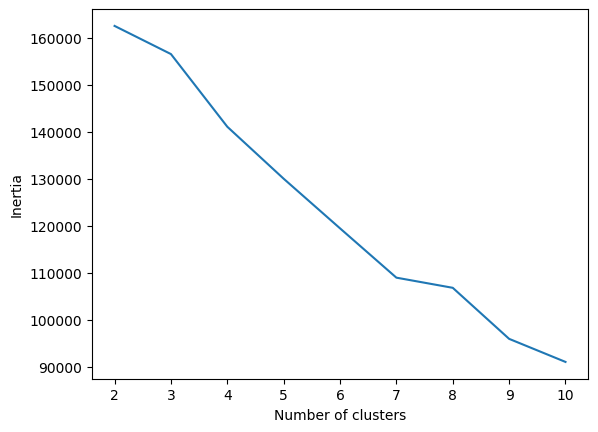

In [16]:
# Create an elbow plot
plot = sns.lineplot(x=num_clusters, y=inertia)
plot.set_xlabel("Number of clusters");
plot.set_ylabel("Inertia");

The plot seems to depict an elbow at seven clusters. It shows that models with more than 7 clusters do not seem to reduce inertia much at all.

**Evaluate silhouette**

In [17]:
 def kmeans_sil(num_clusters, x_vals):
     '''
     Fits a KMeans model for different values of k.
     Calculates a silhouette score for each k value

     Args:
     num_clusters: (list of ints) - The different k values to try
     x_vals:       (array)        - The training data
     
     Returns:
     sil_score:    (list)         - A list of silhouette scores, one for each value of k
     
     '''
     sil_score = []
     for num in num_clusters:
         kms = KMeans(n_clusters=num, random_state=42)
         kms.fit(x_vals)
         sil_score.append(silhouette_score(x_vals, kms.labels_))
     return sil_score

In [18]:
# Calculate silhouette scores for k=2-10
sil_score = kmeans_sil(num_clusters, X_scaled)
sil_score

[np.float64(0.09654835516005061),
 np.float64(0.10735682714140808),
 np.float64(0.15283004800658076),
 np.float64(0.18572903319739476),
 np.float64(0.20808636162010835),
 np.float64(0.2337140173609424),
 np.float64(0.1826768364704893),
 np.float64(0.21641420095102168),
 np.float64(0.19726455252410943)]

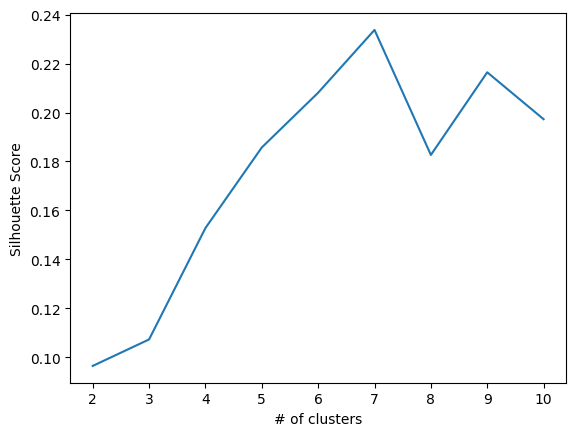

In [19]:
# Create a line plot of silhouette scores
plot = sns.lineplot(x=num_clusters, y=sil_score)
plot.set_xlabel("# of clusters");
plot.set_ylabel("Silhouette Score");

The highest silhouette score shows that a 7-cluster model is optimal. This plot corroborates the findings from the assessment of inertia.

In [20]:
# Instantiate the model and fit a 7-cluster model to the data
kmeans7 = KMeans(n_clusters=7, random_state=42)
kmeans7.fit(X_scaled)

KMeans(n_clusters=7, random_state=42)

In [21]:
# Print unique labels
print('Unique labels:', np.unique(kmeans7.labels_))

Unique labels: [0 1 2 3 4 5 6]


In [22]:
 # Create new column that indicates cluster assignment in original dataframe
df0['cluster'] = kmeans7.labels_
df0.head()

,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date,cluster
0,1,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,Very satisfied with my purchase.,2025-06-22,1
1,2,40,Male,India,41041,4,10,31.73,4,29,0.21,0,Good quality and value for money.,2025-10-17,4
2,3,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,Excellent customer service.,2025-07-01,0
3,4,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,Good quality and value for money.,2025-08-17,3
4,5,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,Excellent customer service.,2025-06-21,3


In [23]:
# Adjust cluster range
df0['cluster'] = df0['cluster'] + 1

In [24]:
# Output unique values
print(df0['cluster'].drop_duplicates().sort_values().tolist())

[1, 2, 3, 4, 5, 6, 7]


In [25]:
# Check cluster column data type
print(df0['cluster'].dtype)

int32


In [26]:
# Display first few rows
df0.head()

,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date,cluster
0,1,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,Very satisfied with my purchase.,2025-06-22,2
1,2,40,Male,India,41041,4,10,31.73,4,29,0.21,0,Good quality and value for money.,2025-10-17,5
2,3,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,Excellent customer service.,2025-07-01,1
3,4,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,Good quality and value for money.,2025-08-17,4
4,5,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,Excellent customer service.,2025-06-21,4


# Visualize
**This part was done with Tableau**

<div class='tableauPlaceholder' id='viz1781441320522' style='position: relative'><noscript><a href='#'><img alt='Dashboard 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Customer_Transactions&#47;Dashboard1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1781441320522');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else { vizElement.style.width='100%';vizElement.style.height='727px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

<div class='tableauPlaceholder' id='viz1780998384353' style='position: relative'><noscript><a href='#'><img alt='Dashboard 2 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard2_1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Customer_Transactions&#47;Dashboard2_1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard2_1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1780998384353');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else { vizElement.style.width='100%';vizElement.style.height='1277px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

<div class='tableauPlaceholder' id='viz1780998459142' style='position: relative'><noscript><a href='#'><img alt='Gender distribution per cluster ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard2&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Customer_Transactions&#47;Dashboard2' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard2&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1780998459142');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else { vizElement.style.width='100%';vizElement.style.height='777px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

<div class='tableauPlaceholder' id='viz1780998508543' style='position: relative'><noscript><a href='#'><img alt='Average age, annual income, spending score and number of purchase per cluster ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard4&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Customer_Transactions&#47;Dashboard4' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard4&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1780998508543');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else { vizElement.style.width='100%';vizElement.style.height='1227px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

<div class='tableauPlaceholder' id='viz1780998561312' style='position: relative'><noscript><a href='#'><img alt='Average membership years, website visits per month and cart abadon rate per cluster ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard3&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Customer_Transactions&#47;Dashboard3' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Cu&#47;Customer_Transactions&#47;Dashboard3&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1780998561312');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.width='1000px';vizElement.style.height='827px';} else { vizElement.style.width='100%';vizElement.style.height='927px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

# Findings

Gender, average age, average spending score, average membership years, average website visits and average cart abadon rate are relatively similar across clusters.

**Cluster 1**

1) Cluster 1 is the largest cluster, containing 3,799 customers (38% of the total) from USA (63% of the cluster, 2,389 customers), Canada (22% of the cluster, 828 customers) and Austrailia (15% of the cluster, 582 customers).

2) 1,896 female customers and 1903 male customers; roughly 50%-50% split.

3) Average annual income (~$100,000).

4) Average age is 44.

5) Average spending score is 51.

6) Average number of purchases is 24.

7) Average membership years is 6.4.

8) Average website visits per month is 15.

9) Average cart abandon rate is 0.50.

**Cluster 2**

1) Cluster 2 has 1,008 customers (~10% of the total) from Germany.

2) 509 female customers and 499 male customers; roughly 50%-50% split.

3) Average annual income is (~$100,000).

4) Average age is 45.

5) Average spending score is 51.

6) Average number of purchases is 24.

7) Average membership years is 6.4.

8) Average website visits per month is 16.

9) Average cart abandon rate is 0.51.


**Cluster 3**

1) Cluster 3 has 1,025 customers (~10% of the total) from Brazil.

2) 500 female customers and 525 male customers; roughly 49%-51% split.

3) Average annual income is (~$50,000).

4) Average age is 44.

5) Average spending score is 50.

6) Average number of purchases is 21.

7) Average membership years is 6.3.

8) Average website visits per month is 16.

9) Average cart abandon rate is 0.50.

**Cluster 4**

1) Cluster 4 has 1,013 customers (~10% of the total) from the UK.

2) 473 female customers and 540 male customers; roughly 47%-53% split.

3) Average annual income is (~$100,000).

4) Average age is 43.

5) Average spending score is 51.

6) Average number of purchases is 23.

7) Average membership years is 6.3.

8) Average website visits per month is 15.

9) Average cart abandon rate is 0.49.


**Cluster 5**

1) Cluster 5 is the second largest cluster, containing 2,266 customers (23% of the total) from India (67% of the cluster, 1524 customers), France (28% of the cluster, 640 customers) and Austrailia (5% of the cluster, 102 customers).

2) 1113 female customers and 1153 male customers; roughly 49%-51% split.

3) Average annual income is (~$50,000).

4) Average age is 44.

5) Average spending score is 50.

6) Average number of purchases is 21.

7) Average membership years is 6.2.

8) Average website visits per month is 16.

9) Average cart abandon rate is 0.50.

**Cluster 6**

1) Cluster 6 has 494 customers (5% of the total) from Japan.

2) 250 female customers and 245 male customers; roughly 51%-49% split.

3) Average annual income is (~$100,000).

4) Average age is 44.

5) Average spending score is 52.

6) Average number of purchases is 23.

7) Average membership years is 6.2.

8) Average website visits per month is 16.

9) Average cart abandon rate is 0.49.

**Cluster 7**

1) Cluster 7 is the smallest cluster, containing 394 customers(4% of the total) from South Africa.

2) 196 female customers and 198 male customers; roughly 50%-50% split.

3) Average annual income is (~$50,000).

4) Average age is 44.

5) Average spending score is 51.

6) Average number of purchases is 21.

7) Average membership years is 6.3.

8) Average website visits per month is 15.

9) Average cart abandon rate is 0.51.